### Cách 1: Dùng SVM
Tiền xử lý dữ liệu đầu vào với
1. Chuyển về chữ thường lowercase
2. Loại bỏ chữ số
3. Bỏ dấu câu
4. Chuẩn hóa giảm thiểu các khoảng trắng

===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         BT1       0.90      0.95      0.93        20
         BT2       0.81      0.85      0.83        20
         BT3       1.00      0.95      0.97        20
         BT4       0.90      0.90      0.90        20
         BT5       1.00      0.95      0.97        20
         BT6       0.95      0.95      0.95        20

    accuracy                           0.93       120
   macro avg       0.93      0.92      0.93       120
weighted avg       0.93      0.93      0.93       120

===== TEST CONFUSION MATRIX =====
[[19  1  0  0  0  0]
 [ 2 17  0  1  0  0]
 [ 0  0 19  0  0  1]
 [ 0  2  0 18  0  0]
 [ 0  1  0  0 19  0]
 [ 0  0  0  1  0 19]]
===== TRAIN CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         BT1       1.00      1.00      1.00        80
         BT2       1.00      1.00      1.00        80
         BT3       1.00      1.00      1.00        80


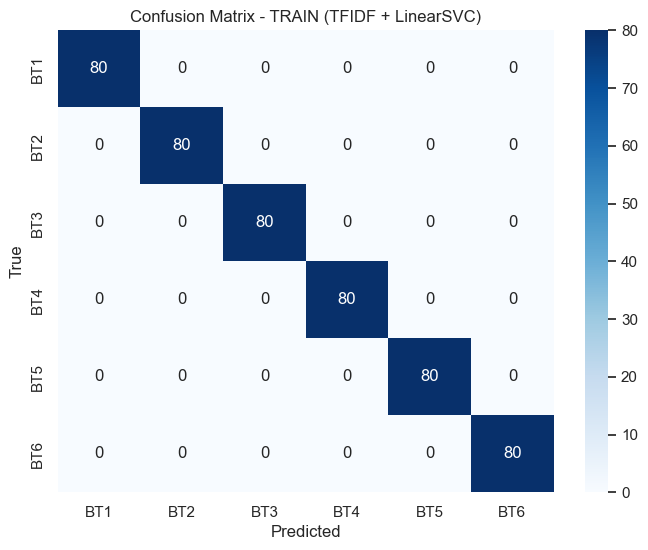

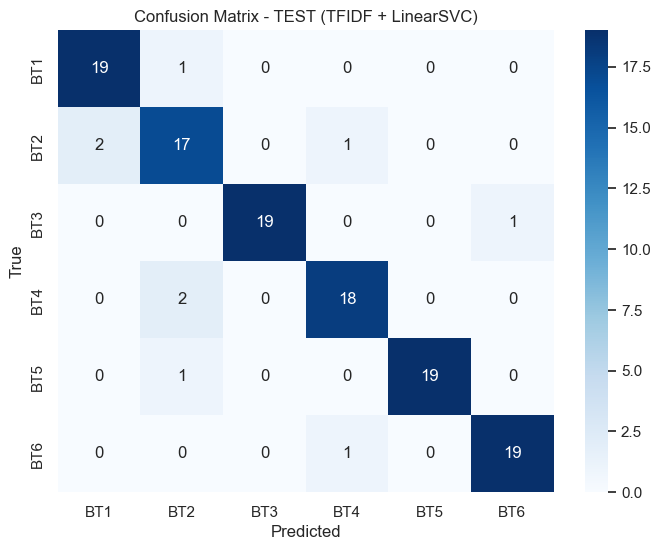

In [43]:
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 1. Load data
# =====================
df = pd.read_csv("../Dataset/OOP.csv")   # columns: question, label

# =====================
# 2. Tiền xử lý tiếng Việt đơn giản
# =====================
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Question"] = df["Question"].apply(preprocess_text)

# =====================
# 3. Train-test split
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    df["Question"],
    df["Label"],
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

# =====================
# 4. Pipeline TF-IDF + SVM
# =====================
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("clf", LinearSVC())
])

# =====================
# 5. Train
# =====================
model.fit(X_train, y_train)

# =====================
# 6. Evaluate TEST
# =====================
y_pred = model.predict(X_test)

print("===== TEST CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

cm_test = confusion_matrix(y_test, y_pred)

print("===== TEST CONFUSION MATRIX =====")
print(cm_test)

# =====================
# 7. Evaluate TRAIN
# =====================
y_train_pred = model.predict(X_train)

print("===== TRAIN CLASSIFICATION REPORT =====")
print(classification_report(y_train, y_train_pred))

cm_train = confusion_matrix(y_train, y_train_pred)

print("===== TRAIN CONFUSION MATRIX =====")
print(cm_train)

# Lấy danh sách label theo thứ tự
labels = sorted(df["Label"].unique())

# =====================
# 8. Vẽ heatmap
# =====================
sns.set_theme(style="white")

# ---- TRAIN HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - TRAIN (TFIDF + LinearSVC)")
plt.show()

# ---- TEST HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - TEST (TFIDF + LinearSVC)")
plt.show()

#### Dự đoán trên bộ dữ liệu random mới 50 câu

In [44]:
# =====================
# 7. Load file test.csv
# =====================
test_df = pd.read_csv("../Dataset/test.csv")

# Tiền xử lý giống train
test_df["Question"] = test_df["Question"].apply(preprocess_text)

# Lưu nhãn thật (để tính accuracy)
true_labels = test_df["Label"]

# =====================
# 8. Dự đoán
# =====================
pred_labels = model.predict(test_df["Question"])

# =====================
# 9. Tính accuracy
# =====================
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, pred_labels)
print(f"Accuracy trên test.csv: {accuracy * 100:.2f}%")

# In báo cáo chi tiết
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels))

Accuracy trên test.csv: 100.00%

Classification Report:
              precision    recall  f1-score   support

         BT1       1.00      1.00      1.00         9
         BT2       1.00      1.00      1.00         8
         BT3       1.00      1.00      1.00         8
         BT4       1.00      1.00      1.00         9
         BT5       1.00      1.00      1.00         8
         BT6       1.00      1.00      1.00         8

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



### Thử nghiệm lại với file test2
Câu lệnh sinh test2: Cho tôi 50 câu với nhãn random theo thang Bloom chưa từng sinh ở tất cả các lần trước

Tỉ lệ dự đoán chính xác trên bộ TEST: 96.00%


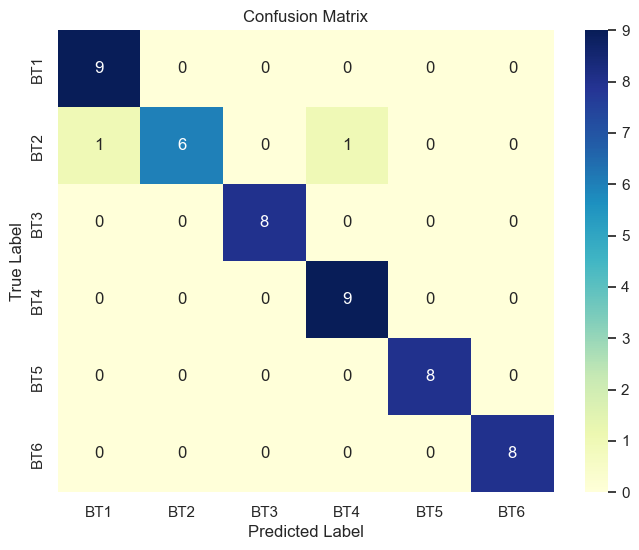


===== Accuracy từng nhãn =====
Label BT1: 100.00% (9/9)
Label BT2: 75.00% (6/8)
Label BT3: 100.00% (8/8)
Label BT4: 100.00% (9/9)
Label BT5: 100.00% (8/8)
Label BT6: 100.00% (8/8)


In [ ]:
# =====================
# 7. Load file test.csv
# =====================
test_df = pd.read_csv("../Dataset/test2.csv")

# Tiền xử lý giống train
test_df["Question"] = test_df["Question"].apply(preprocess_text)

# Lưu nhãn thật (để tính accuracy)
true_labels = test_df["Label"]

# =====================
# 8. Dự đoán
# =====================
pred_labels = model.predict(test_df["Question"])

# =====================
# 9. Tính accuracy
# =====================
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, pred_labels)
print(f"Tỉ lệ dự đoán chính xác trên bộ TEST: {accuracy * 100:.2f}%")

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",   # màu sáng
    xticklabels=np.unique(true_labels),
    yticklabels=np.unique(true_labels)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# =====================
# 10. Accuracy theo từng nhãn
# =====================
print("\n===== Accuracy từng nhãn =====")

labels = np.unique(true_labels)

for i, label in enumerate(labels):
    correct = cm[i, i]              
    total = np.sum(cm[i, :])       
    
    acc = correct / total if total != 0 else 0
    
    print(f"Label {label}: {acc*100:.2f}% ({correct}/{total})")

### Sử dụng PhoBert
3 epochs
learning rate = 2.5 * 10^-5

Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



================ EPOCH 1 ================


100%|██████████| 60/60 [00:01<00:00, 31.96it/s]



Train Loss: 1.7626
Train Accuracy: 0.2479
Train F1: 0.2440

--- TRAIN REPORT ---
              precision    recall  f1-score   support

         BT1       0.24      0.39      0.30        80
         BT2       0.19      0.23      0.20        80
         BT3       0.20      0.25      0.22        80
         BT4       0.28      0.14      0.18        80
         BT5       0.28      0.16      0.21        80
         BT6       0.39      0.33      0.35        80

    accuracy                           0.25       480
   macro avg       0.26      0.25      0.24       480
weighted avg       0.26      0.25      0.24       480


Validation Accuracy: 0.6417
Validation F1: 0.6303

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

         BT1       0.84      0.80      0.82        20
         BT2       0.56      0.25      0.34        20
         BT3       0.42      0.80      0.55        20
         BT4       0.53      0.40      0.46        20
         BT5       0.76   

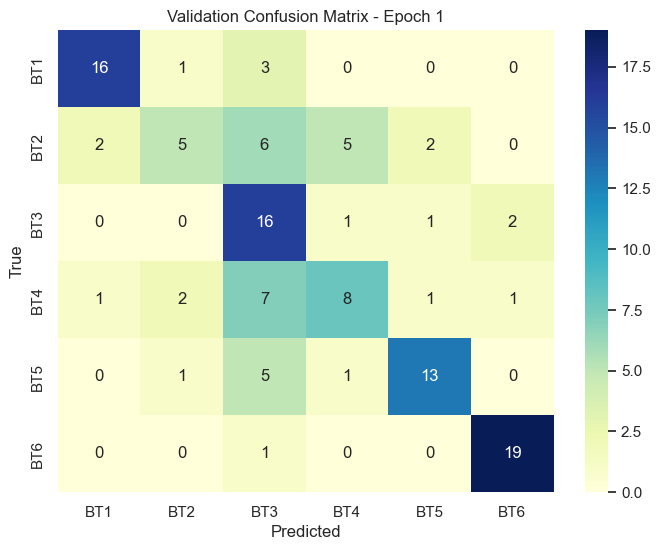


================ EPOCH 2 ================


100%|██████████| 60/60 [00:01<00:00, 32.47it/s]



Train Loss: 1.4689
Train Accuracy: 0.6292
Train F1: 0.6221

--- TRAIN REPORT ---
              precision    recall  f1-score   support

         BT1       0.67      0.75      0.71        80
         BT2       0.62      0.42      0.50        80
         BT3       0.52      0.75      0.62        80
         BT4       0.69      0.41      0.52        80
         BT5       0.87      0.60      0.71        80
         BT6       0.57      0.84      0.68        80

    accuracy                           0.63       480
   macro avg       0.66      0.63      0.62       480
weighted avg       0.66      0.63      0.62       480


Validation Accuracy: 0.8333
Validation F1: 0.8312

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

         BT1       0.74      0.85      0.79        20
         BT2       0.85      0.55      0.67        20
         BT3       0.90      0.90      0.90        20
         BT4       0.68      0.85      0.76        20
         BT5       1.00   

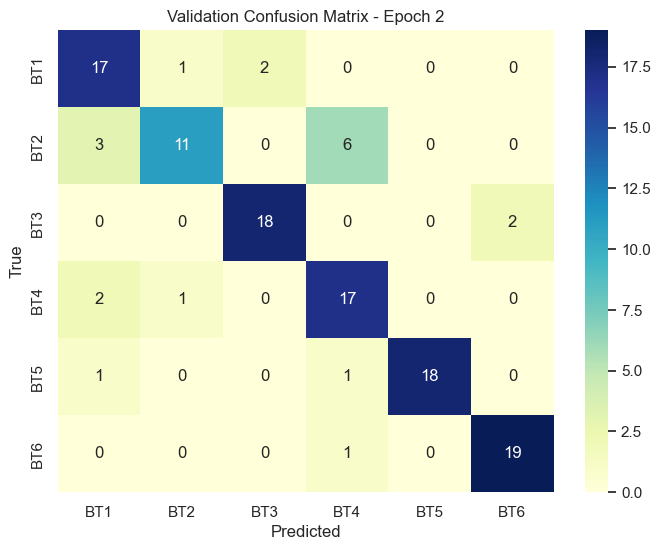


================ EPOCH 3 ================


100%|██████████| 60/60 [00:01<00:00, 32.48it/s]



Train Loss: 1.1027
Train Accuracy: 0.7854
Train F1: 0.7853

--- TRAIN REPORT ---
              precision    recall  f1-score   support

         BT1       0.76      0.82      0.79        80
         BT2       0.69      0.65      0.67        80
         BT3       0.86      0.80      0.83        80
         BT4       0.72      0.72      0.72        80
         BT5       0.98      0.76      0.86        80
         BT6       0.75      0.95      0.84        80

    accuracy                           0.79       480
   macro avg       0.80      0.79      0.79       480
weighted avg       0.80      0.79      0.79       480


Validation Accuracy: 0.8667
Validation F1: 0.8648

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

         BT1       0.86      0.90      0.88        20
         BT2       0.76      0.65      0.70        20
         BT3       0.95      0.90      0.92        20
         BT4       0.76      0.80      0.78        20
         BT5       1.00   

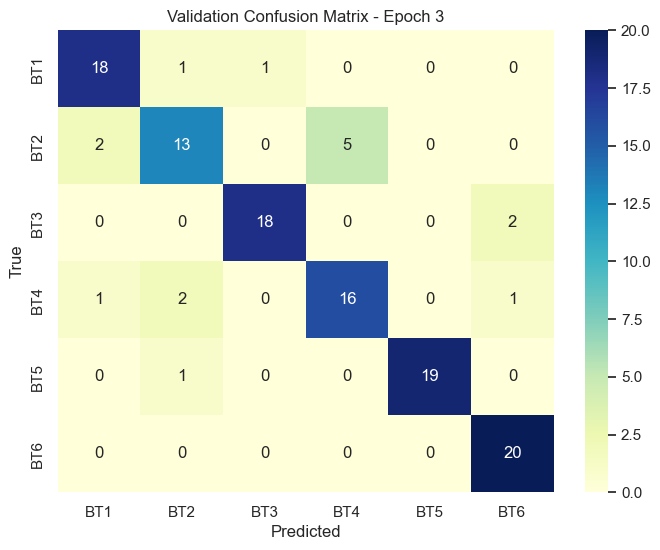


================ EPOCH 4 ================


100%|██████████| 60/60 [00:01<00:00, 32.44it/s]



Train Loss: 0.8350
Train Accuracy: 0.8562
Train F1: 0.8557

--- TRAIN REPORT ---
              precision    recall  f1-score   support

         BT1       0.80      0.91      0.85        80
         BT2       0.74      0.69      0.71        80
         BT3       0.95      0.88      0.91        80
         BT4       0.80      0.80      0.80        80
         BT5       0.99      0.89      0.93        80
         BT6       0.88      0.97      0.92        80

    accuracy                           0.86       480
   macro avg       0.86      0.86      0.86       480
weighted avg       0.86      0.86      0.86       480


Validation Accuracy: 0.8917
Validation F1: 0.8891

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

         BT1       0.86      0.95      0.90        20
         BT2       0.87      0.65      0.74        20
         BT3       1.00      0.90      0.95        20
         BT4       0.77      0.85      0.81        20
         BT5       1.00   

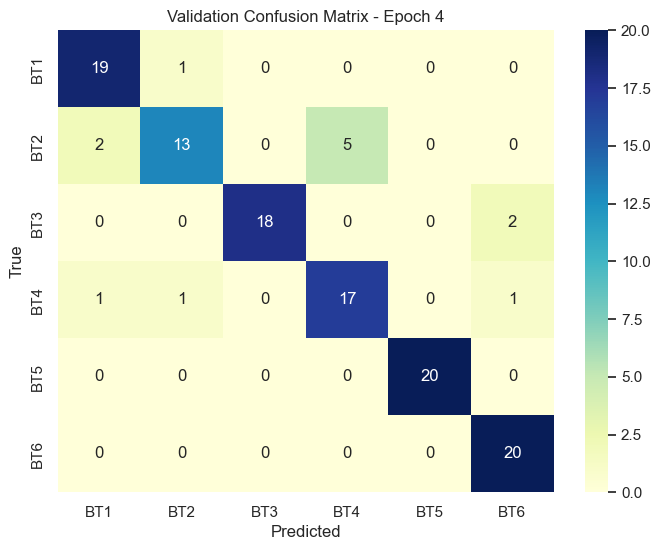


================ EPOCH 5 ================


100%|██████████| 60/60 [00:01<00:00, 32.51it/s]



Train Loss: 0.7088
Train Accuracy: 0.8771
Train F1: 0.8758

--- TRAIN REPORT ---
              precision    recall  f1-score   support

         BT1       0.83      0.95      0.88        80
         BT2       0.78      0.70      0.74        80
         BT3       0.95      0.89      0.92        80
         BT4       0.85      0.82      0.84        80
         BT5       0.99      0.91      0.95        80
         BT6       0.89      0.99      0.93        80

    accuracy                           0.88       480
   macro avg       0.88      0.88      0.88       480
weighted avg       0.88      0.88      0.88       480


Validation Accuracy: 0.8917
Validation F1: 0.8891

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

         BT1       0.86      0.95      0.90        20
         BT2       0.87      0.65      0.74        20
         BT3       1.00      0.90      0.95        20
         BT4       0.77      0.85      0.81        20
         BT5       1.00   

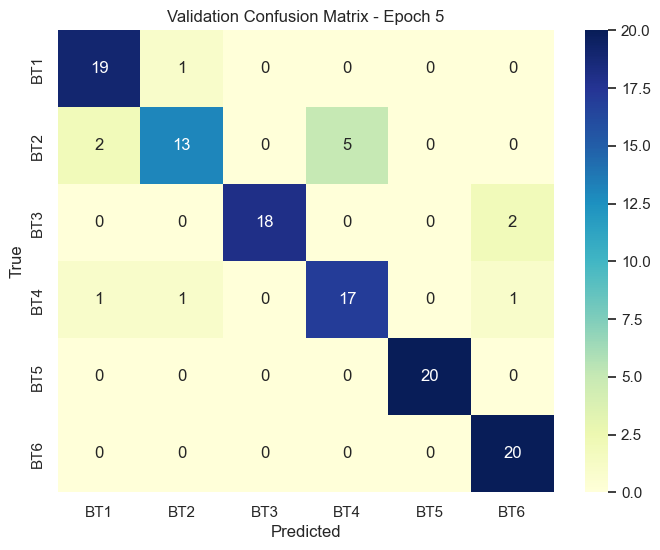


Loading TEST set...

===== TEST RESULTS =====
Test Accuracy: 0.96
Test F1: 0.9616

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         BT1       0.90      1.00      0.95         9
         BT2       1.00      0.88      0.93         8
         BT3       1.00      1.00      1.00         8
         BT4       0.89      0.89      0.89         9
         BT5       1.00      1.00      1.00         8
         BT6       1.00      1.00      1.00         8

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



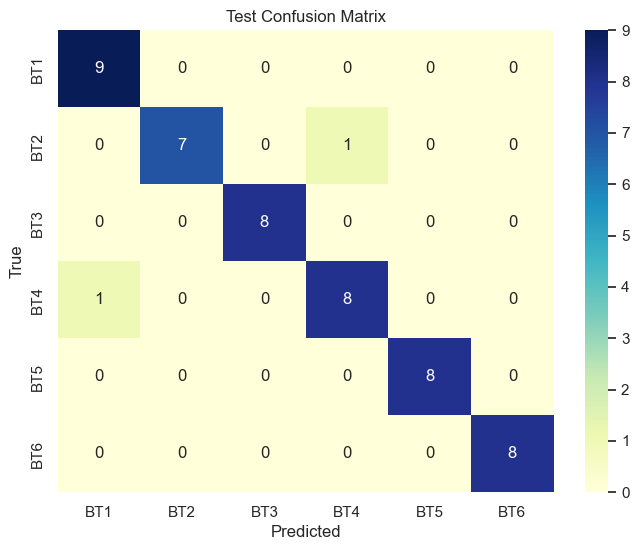

In [46]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. Device
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ======================
# 2. Load TRAIN data
# ======================
df = pd.read_csv("../Dataset/OOP.csv")

label_encoder = LabelEncoder()
df["Label"] = label_encoder.fit_transform(df["Label"])

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

# ======================
# 3. Load PhoBERT
# ======================
model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class BloomDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = BloomDataset(train_df["Question"].tolist(), train_df["Label"].tolist())
val_dataset = BloomDataset(val_df["Question"].tolist(), val_df["Label"].tolist())

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# ======================
# 4. Model
# ======================
num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# Freeze 8 layers đầu
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

for layer in model.roberta.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False

model.to(device)

# ======================
# 5. Optimizer + Scheduler
# ======================
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
criterion = nn.CrossEntropyLoss()

epochs = 5
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ======================
# 6. Training
# ======================
for epoch in range(epochs):
    print(f"\n================ EPOCH {epoch+1} ================")

    # TRAIN
    model.train()
    total_loss = 0
    train_preds, train_labels = [], []

    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    print(f"\nTrain Loss: {total_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Train F1: {train_f1:.4f}")

    print("\n--- TRAIN REPORT ---")
    print(classification_report(train_labels, train_preds, target_names=label_encoder.classes_))

    # VALIDATION
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    print(f"\nValidation Accuracy: {val_acc:.4f}")
    print(f"Validation F1: {val_f1:.4f}")

    print("\n--- VALIDATION REPORT ---")
    print(classification_report(val_labels, val_preds, target_names=label_encoder.classes_))

    # Confusion matrix VAL
    cm_val = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_val, annot=True, fmt="d", cmap="YlGnBu",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Validation Confusion Matrix - Epoch {epoch+1}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ======================
# 7. TEST
# ======================
print("\nLoading TEST set...")
test_df = pd.read_csv("../Dataset/test.csv")
test_df = test_df[test_df["Label"].isin(label_encoder.classes_)]
test_df["Label"] = label_encoder.transform(test_df["Label"])

test_dataset = BloomDataset(
    test_df["Question"].tolist(),
    test_df["Label"].tolist()
)
test_loader = DataLoader(test_dataset, batch_size=8)

model.eval()
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1 = f1_score(all_test_labels, all_test_preds, average="macro")

print("\n===== TEST RESULTS =====")
print("Test Accuracy:", round(test_acc, 4))
print("Test F1:", round(test_f1, 4))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(all_test_labels, all_test_preds, target_names=label_encoder.classes_))

cm = confusion_matrix(all_test_labels, all_test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()